In [1]:
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
import os

# Reload the module to get latest changes
import importlib
import icemodels
import icemodels.plot_seds
importlib.reload(icemodels.plot_seds)
importlib.reload(icemodels)

from icemodels import plot_stellar_seds, optical_constants_cache_dir, read_ocdb_file
from icemodels import fluxes_in_filters, atmo_model, absorbed_spectrum
from astroquery.svo_fps import SvoFps

%matplotlib inline

## Example 1: Multiple Temperatures

Plot SEDs for stars at different temperatures (cool M dwarf, solar-type, and hot star).

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


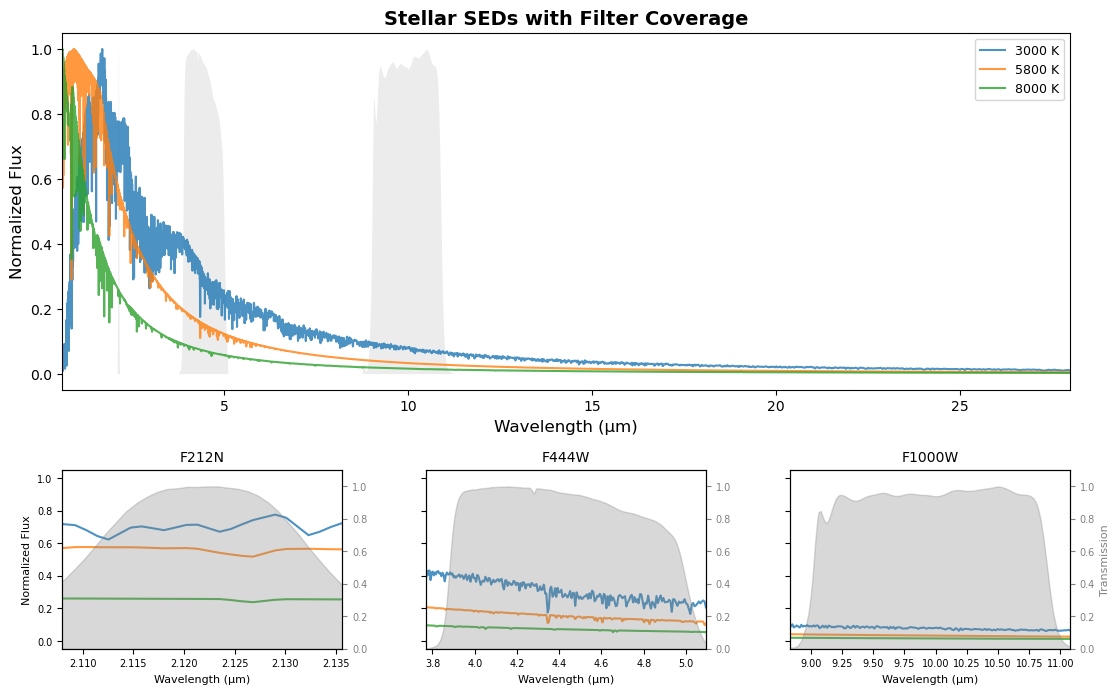

In [2]:
# Define temperatures and filters
temperatures = [3000, 5800, 8000]  # M dwarf, Sun-like, A-type star
filters = ['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W', 'JWST/MIRI.F1000W']

fig, axes = plot_stellar_seds(temperatures=temperatures, filters=filters, logg=2.5)
plt.show()

In [3]:
# Compute colors (magnitude differences) for Example 1
# Get filter info
jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')
filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in filters}
transdata = {fid: SvoFps.get_transmission_data(fid) for fid in filters}

print("\nComputed Colors (magnitude differences):")
print("=" * 70)

for temp in temperatures:
    # Generate stellar model and compute filter fluxes
    xarr_ex1 = np.linspace(0.6*u.um, 28.0*u.um, 25000)
    stellar_model = atmo_model(temp, xarr=xarr_ex1)
    fluxes_sed = fluxes_in_filters(xarr_ex1, stellar_model['fnu'].quantity, 
                                   filterids=filters, transdata=transdata)
    
    # Convert to magnitudes
    mags = {filt.replace('JWST/NIRCam.', '').replace('JWST/MIRI.', ''): 
            -2.5 * np.log10(fluxes_sed[filt] / u.Quantity(filter_data[filt], u.Jy))
            for filt in filters}
    
    # Compute colors (differences between adjacent filters)
    filt_names = list(mags.keys())
    print(f"\n{temp}K:")
    for i in range(len(filt_names)-1):
        color = mags[filt_names[i]] - mags[filt_names[i+1]]
        print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print("=" * 70)


Computed Colors (magnitude differences):



3000K:
  [F212N] - [F444W]: +0.142
  [F444W] - [F1000W]: +0.188

5800K:
  [F212N] - [F444W]: +0.018
  [F444W] - [F1000W]: +0.024

8000K:
  [F212N] - [F444W]: +0.107
  [F444W] - [F1000W]: +0.075


## Example 2: With Ice Absorption

Show how ice absorption affects the stellar SED.

Using CO2 file: /blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/data/ocdb_55_CO2_(1)_8K_Gerakines.txt
Using CO file: /blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/data/63_CO_(1)_25K_Gerakines.txt


/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


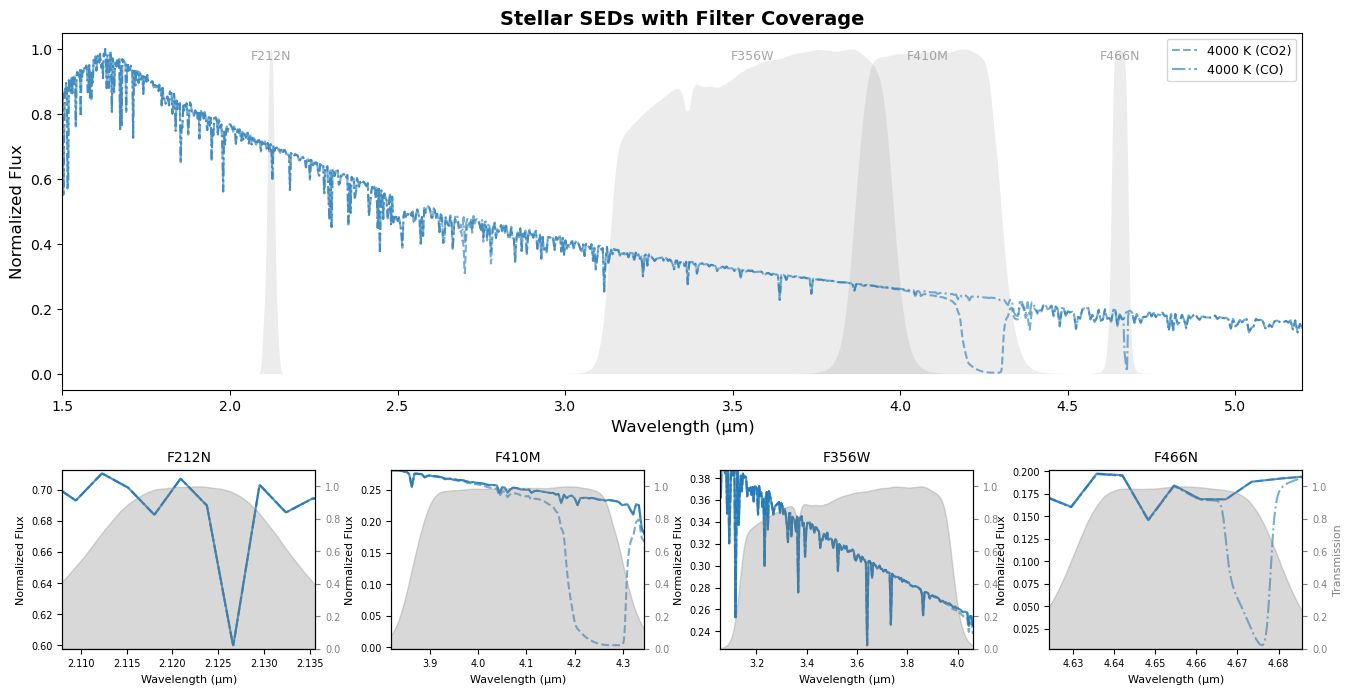

In [4]:
# Load ice optical constants from OCDB for both CO2 and CO
import glob

# Find CO2 and CO ice files from Gerakines
co2_files = glob.glob(f'{optical_constants_cache_dir}/*_CO2_(1)_*K_Gerakines*.txt')
co_files = glob.glob(f'{optical_constants_cache_dir}/*_CO_(1)_*K_Gerakines*.txt')
h2o_files = glob.glob(f'{optical_constants_cache_dir}/*_H2O_(1)_*K_Mastrapa*.txt')
if h2o_files:
    h2o_table = read_ocdb_file(h2o_files[0])

xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

if co2_files and co_files:
    # Load both ice tables
    co2_table = read_ocdb_file(co2_files[0])
    co_table = read_ocdb_file(co_files[0])
    
    print(f"Using CO2 file: {co2_files[0]}")
    print(f"Using CO file: {co_files[0]}")
    
    # Plot with both CO2 and CO ice absorption
    fig, axes = plot_stellar_seds(
        xarr=xarr_custom,
        temperatures=4000,
        logg=2.5,
        filters=['JWST/NIRCam.F212N', 'JWST/NIRCam.F410M', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F466N'],
        ice_model_table=[co2_table, co_table],
        ice_column=[1e18*u.cm**-2, 1e18*u.cm**-2],  # Same column for both
        molecular_weight=[44*u.Da, 28*u.Da],  # CO2 and CO
        ice_labels=['CO2', 'CO'],
        renormalize_insets=True,
    label_filters=True,
    )
    plt.show()
else:
    if not co2_files:
        print("No CO2 ice files found.")
    if not co_files:
        print("No CO ice files found.")
    print("Run download_all_ocdb() first to download ice data.")

In [5]:
# Compute colors for Example 2 - showing ice absorption effects
if co2_files and co_files:
    example_filters = ['JWST/NIRCam.F212N', 'JWST/NIRCam.F410M', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F466N']
    
    # Get filter info
    filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in example_filters}
    transdata = {fid: SvoFps.get_transmission_data(fid) for fid in example_filters}
    
    # Generate baseline stellar model
    stellar_model = atmo_model(4000, xarr=xarr_custom)
    base_fluxes = stellar_model['fnu'].quantity
    
    # Compute baseline filter fluxes
    base_filter_fluxes = fluxes_in_filters(xarr_custom, base_fluxes, 
                                          filterids=example_filters, transdata=transdata)
    
    # Compute CO2 ice-absorbed spectrum
    co2_absorbed = absorbed_spectrum(ice_column=1e18*u.cm**-2, ice_model_table=co2_table,
                                    spectrum=base_fluxes, xarr=xarr_custom, molecular_weight=44*u.Da)
    co2_filter_fluxes = fluxes_in_filters(xarr_custom, co2_absorbed, 
                                         filterids=example_filters, transdata=transdata)
    
    # Compute CO ice-absorbed spectrum
    co_absorbed = absorbed_spectrum(ice_column=1e18*u.cm**-2, ice_model_table=co_table,
                                   spectrum=base_fluxes, xarr=xarr_custom, molecular_weight=28*u.Da)
    co_filter_fluxes = fluxes_in_filters(xarr_custom, co_absorbed, 
                                        filterids=example_filters, transdata=transdata)
    
    # Convert to magnitudes
    base_mags = {filt.replace('JWST/NIRCam.', ''): 
                 -2.5 * np.log10(base_filter_fluxes[filt] / u.Quantity(filter_data[filt], u.Jy))
                 for filt in example_filters}
    co2_mags = {filt.replace('JWST/NIRCam.', ''): 
                -2.5 * np.log10(co2_filter_fluxes[filt] / u.Quantity(filter_data[filt], u.Jy))
                for filt in example_filters}
    co_mags = {filt.replace('JWST/NIRCam.', ''): 
               -2.5 * np.log10(co_filter_fluxes[filt] / u.Quantity(filter_data[filt], u.Jy))
               for filt in example_filters}
    
    print("\nComputed Colors - Ice Absorption Effects:")
    print("=" * 70)
    
    filt_names = list(base_mags.keys())
    
    print("\n4000K (no ice):")
    for i in range(len(filt_names)-1):
        color = base_mags[filt_names[i]] - base_mags[filt_names[i+1]]
        print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")
    
    print("\n4000K (CO2 ice, N=1e18 cm^-2):")
    for i in range(len(filt_names)-1):
        color = co2_mags[filt_names[i]] - co2_mags[filt_names[i+1]]
        delta = (co2_mags[filt_names[i]] - co2_mags[filt_names[i+1]]) - (base_mags[filt_names[i]] - base_mags[filt_names[i+1]])
        print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}  (Δcolor: {delta:+6.3f})")
    
    print("\n4000K (CO ice, N=1e18 cm^-2):")
    for i in range(len(filt_names)-1):
        color = co_mags[filt_names[i]] - co_mags[filt_names[i+1]]
        delta = (co_mags[filt_names[i]] - co_mags[filt_names[i+1]]) - (base_mags[filt_names[i]] - base_mags[filt_names[i+1]])
        print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}  (Δcolor: {delta:+6.3f})")
    
    print("=" * 70)


Computed Colors - Ice Absorption Effects:

4000K (no ice):
  [F212N] - [F410M]: +0.111
  [F410M] - [F356W]: -0.027
  [F356W] - [F466N]: -0.101

4000K (CO2 ice, N=1e18 cm^-2):
  [F212N] - [F410M]: -0.186  (Δcolor: -0.297)
  [F410M] - [F356W]: +0.269  (Δcolor: +0.296)
  [F356W] - [F466N]: -0.101  (Δcolor: +0.000)

4000K (CO ice, N=1e18 cm^-2):
  [F212N] - [F410M]: +0.111  (Δcolor: -0.000)
  [F410M] - [F356W]: -0.027  (Δcolor: -0.000)
  [F356W] - [F466N]: -0.287  (Δcolor: -0.186)


Using CO2 file: /blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/data/ocdb_55_CO2_(1)_8K_Gerakines.txt
Using CO file: /blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/data/63_CO_(1)_25K_Gerakines.txt


/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


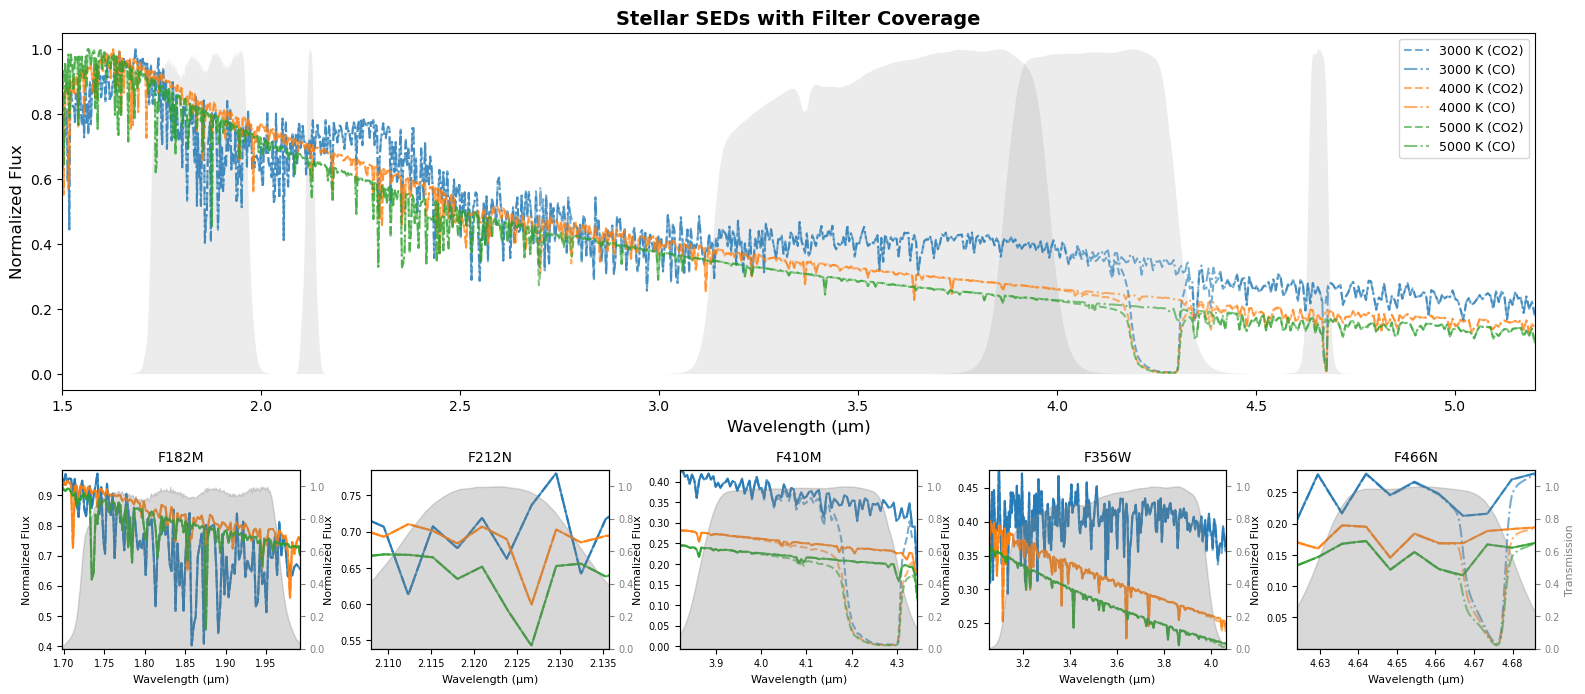

In [6]:
# Load ice optical constants from OCDB for both CO2 and CO
import glob

# Find CO2 and CO ice files from Gerakines
co2_files = glob.glob(f'{optical_constants_cache_dir}/*_CO2_(1)_*K_Gerakines*.txt')
co_files = glob.glob(f'{optical_constants_cache_dir}/*_CO_(1)_*K_Gerakines*.txt')

xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

if co2_files and co_files:
    # Load both ice tables
    co2_table = read_ocdb_file(co2_files[0])
    co_table = read_ocdb_file(co_files[0])
    
    print(f"Using CO2 file: {co2_files[0]}")
    print(f"Using CO file: {co_files[0]}")
    
    # Plot with both CO2 and CO ice absorption
    fig, axes = plot_stellar_seds(
        xarr=xarr_custom,
        temperatures=[3000, 4000, 5000],
        logg=2.5,
        filters=['JWST/NIRCam.F182M', 'JWST/NIRCam.F212N', 'JWST/NIRCam.F410M', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F466N'],
        ice_model_table=[co2_table, co_table],
        ice_column=[1e18*u.cm**-2, 1e18*u.cm**-2],  # Same column for both
        molecular_weight=[44*u.Da, 28*u.Da],  # CO2 and CO
        ice_labels=['CO2', 'CO'],
        renormalize_insets=True,
    )
    plt.show()
else:
    if not co2_files:
        print("No CO2 ice files found.")
    if not co_files:
        print("No CO ice files found.")
    print("Run download_all_ocdb() first to download ice data.")

In [7]:
# Compute colors for multi-temperature + ice example
if co2_files and co_files:
    example_filters = ['JWST/NIRCam.F182M', 'JWST/NIRCam.F212N', 'JWST/NIRCam.F410M', 
                      'JWST/NIRCam.F356W', 'JWST/NIRCam.F466N']
    
    filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in example_filters}
    transdata = {fid: SvoFps.get_transmission_data(fid) for fid in example_filters}
    
    print("\nComputed Colors - Multiple Temperatures with Ice:")
    print("=" * 70)
    
    for temp in [3000, 4000, 5000]:
        stellar_model = atmo_model(temp, xarr=xarr_custom)
        base_fluxes = stellar_model['fnu'].quantity
        
        base_filter_fluxes = fluxes_in_filters(xarr_custom, base_fluxes, 
                                              filterids=example_filters, transdata=transdata)
        base_mags = {filt.replace('JWST/NIRCam.', ''): 
                    -2.5 * np.log10(base_filter_fluxes[filt] / u.Quantity(filter_data[filt], u.Jy))
                    for filt in example_filters}
        
        filt_names = list(base_mags.keys())
        print(f"\n{temp}K (no ice):")
        for i in range(len(filt_names)-1):
            color = base_mags[filt_names[i]] - base_mags[filt_names[i+1]]
            print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")
    
    print("=" * 70)


Computed Colors - Multiple Temperatures with Ice:



3000K (no ice):
  [F182M] - [F212N]: +0.204
  [F212N] - [F410M]: +0.289
  [F410M] - [F356W]: -0.140
  [F356W] - [F466N]: -0.070

4000K (no ice):
  [F182M] - [F212N]: +0.003
  [F212N] - [F410M]: +0.111
  [F410M] - [F356W]: -0.027
  [F356W] - [F466N]: -0.101

5000K (no ice):
  [F182M] - [F212N]: +0.013
  [F212N] - [F410M]: +0.040
  [F410M] - [F356W]: -0.009
  [F356W] - [F466N]: +0.012


## Example 3: Custom Wavelength Range

Focus on a specific wavelength range for higher resolution.

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


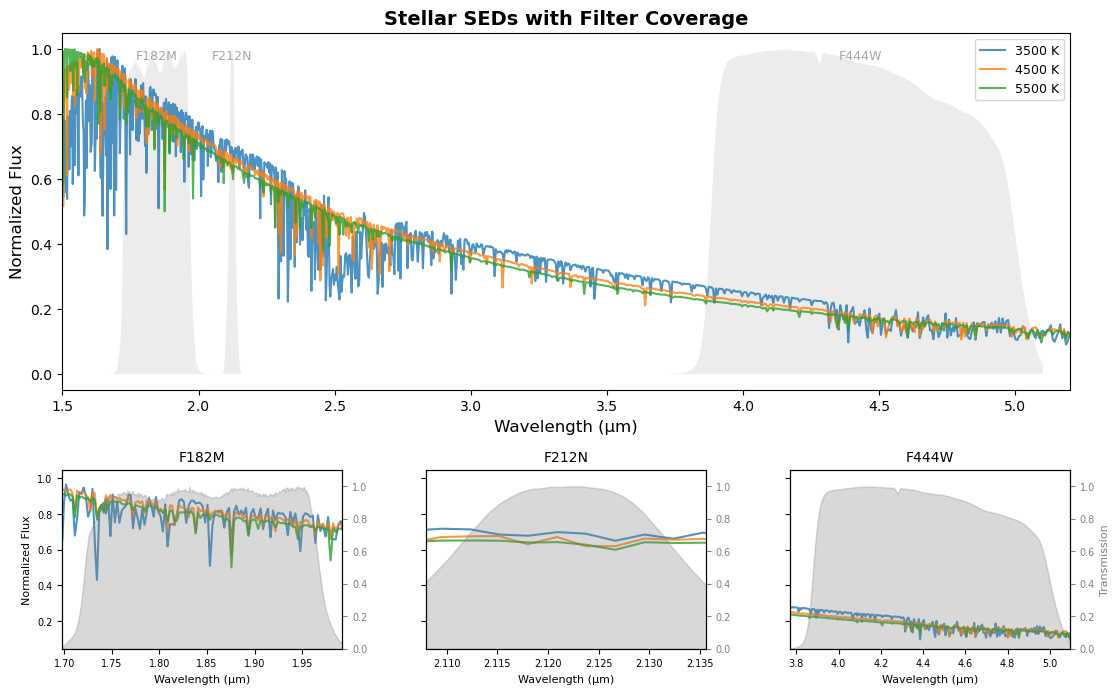

In [8]:
# Custom wavelength array focused on NIR
xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

fig, axes = plot_stellar_seds(
    temperatures=[3500, 4500, 5500],
    logg=2.5,
    filters=['JWST/NIRCam.F182M', 'JWST/NIRCam.F212N', 'JWST/NIRCam.F444W'],
    xarr=xarr_custom,
    label_filters=True,

)
plt.show()

In [9]:
# Compute colors for Example 3
example_filters = ['JWST/NIRCam.F182M', 'JWST/NIRCam.F212N', 'JWST/NIRCam.F444W']
filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in example_filters}
transdata = {fid: SvoFps.get_transmission_data(fid) for fid in example_filters}

print("\nComputed Colors:")
print("=" * 70)

for temp in [3500, 4500, 5500]:
    stellar_model = atmo_model(temp, xarr=xarr_custom)
    filter_fluxes = fluxes_in_filters(xarr_custom, stellar_model['fnu'].quantity, 
                                     filterids=example_filters, transdata=transdata)
    
    mags = {filt.replace('JWST/NIRCam.', ''): 
            -2.5 * np.log10(filter_fluxes[filt] / u.Quantity(filter_data[filt], u.Jy))
            for filt in example_filters}
    
    filt_names = list(mags.keys())
    print(f"\n{temp}K:")
    for i in range(len(filt_names)-1):
        color = mags[filt_names[i]] - mags[filt_names[i+1]]
        print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print("=" * 70)


Computed Colors:



3500K:
  [F182M] - [F212N]: +0.088
  [F212N] - [F444W]: +0.108

4500K:
  [F182M] - [F212N]: +0.023
  [F212N] - [F444W]: +0.012

5500K:
  [F182M] - [F212N]: -0.007
  [F212N] - [F444W]: +0.053


## Example 4: Many Filters

Demonstrate the layout with many filters.

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


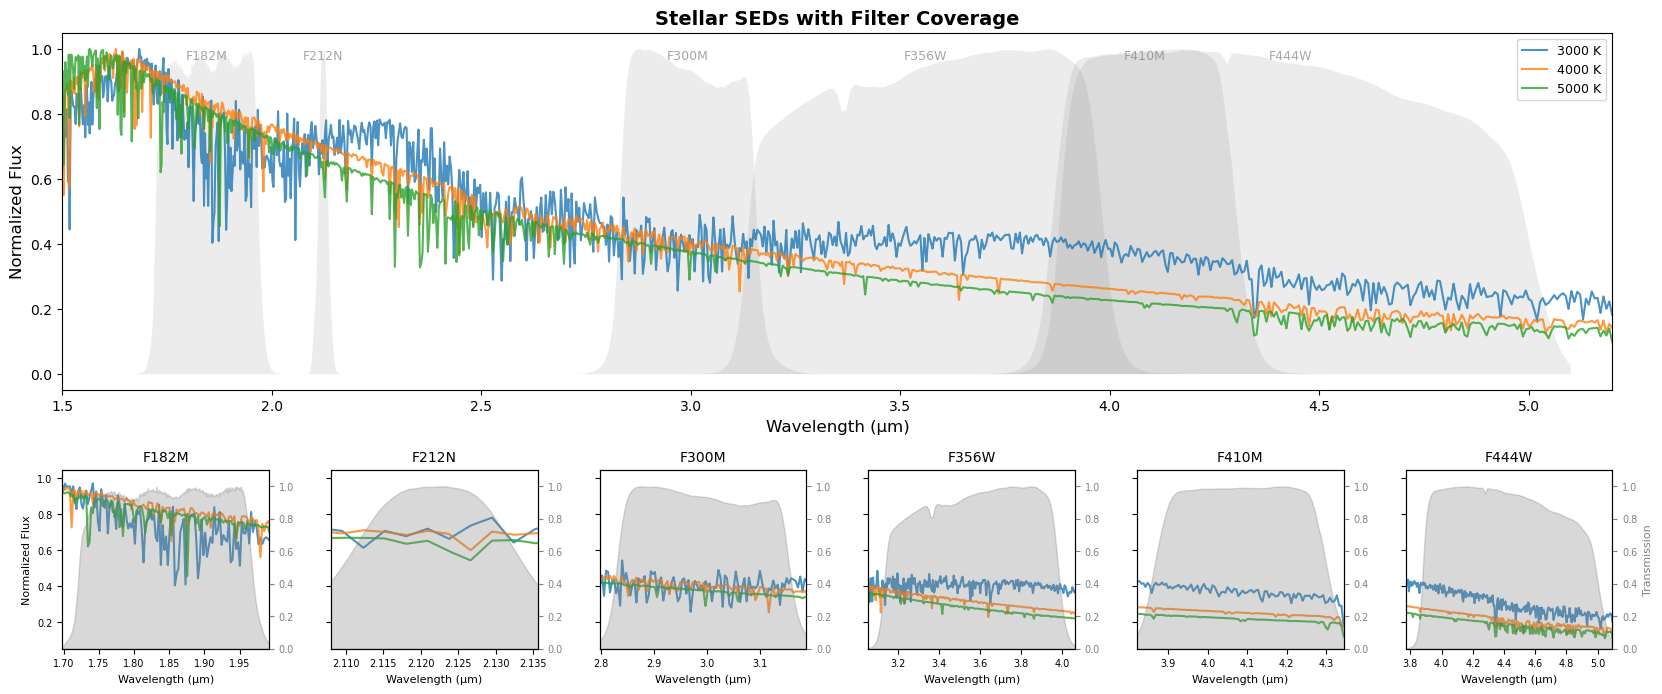

In [10]:
many_filters = [
    'JWST/NIRCam.F182M',
    'JWST/NIRCam.F212N',
    'JWST/NIRCam.F300M',
    'JWST/NIRCam.F356W',
    'JWST/NIRCam.F410M',
    'JWST/NIRCam.F444W',
]

xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

fig, axes = plot_stellar_seds(
    temperatures=[3000, 4000, 5000],
    logg=2.5,
    filters=many_filters,
    figsize=(20, 8), 
    xarr=xarr_custom,
    label_filters=True,
)
plt.show()

In [11]:
# Compute colors for Example 4 (many filters)
filter_data = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in many_filters}
transdata = {fid: SvoFps.get_transmission_data(fid) for fid in many_filters}

print("\nComputed Colors:")
print("=" * 70)

for temp in [3000, 4000, 5000]:
    stellar_model = atmo_model(temp, xarr=xarr_custom)
    filter_fluxes = fluxes_in_filters(xarr_custom, stellar_model['fnu'].quantity, 
                                     filterids=many_filters, transdata=transdata)
    
    mags = {filt.replace('JWST/NIRCam.', ''): 
            -2.5 * np.log10(filter_fluxes[filt] / u.Quantity(filter_data[filt], u.Jy))
            for filt in many_filters}
    
    filt_names = list(mags.keys())
    print(f"\n{temp}K:")
    for i in range(len(filt_names)-1):
        color = mags[filt_names[i]] - mags[filt_names[i+1]]
        print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print("=" * 70)


Computed Colors:



3000K:
  [F182M] - [F212N]: +0.204
  [F212N] - [F300M]: -0.282
  [F300M] - [F356W]: +0.431
  [F356W] - [F410M]: +0.140
  [F410M] - [F444W]: -0.147

4000K:
  [F182M] - [F212N]: +0.003
  [F212N] - [F300M]: +0.048
  [F300M] - [F356W]: +0.036
  [F356W] - [F410M]: +0.027
  [F410M] - [F444W]: -0.075

5000K:
  [F182M] - [F212N]: +0.013
  [F212N] - [F300M]: +0.031
  [F300M] - [F356W]: -0.000
  [F356W] - [F410M]: +0.009
  [F410M] - [F444W]: -0.036


## Example 5: Stellar SEDs with Interstellar Extinction

Apply interstellar extinction using the Chiar & Tielens 2006 (CT06) extinction curve.

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


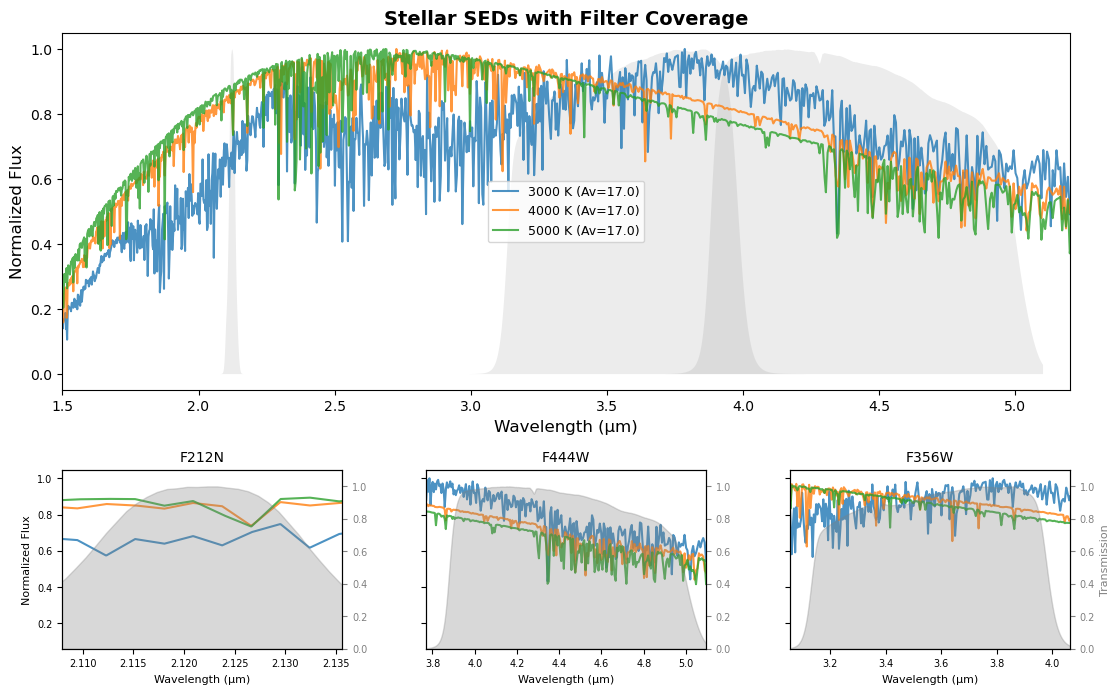

In [12]:
xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

from dust_extinction.averages import CT06_MWGC

# Reload to pick up extinction changes
import importlib
import icemodels.plot_seds
importlib.reload(icemodels.plot_seds)
from icemodels import plot_stellar_seds

# Plot with 17 mag of CT06 extinction
fig, axes = plot_stellar_seds(
    temperatures=[3000, 4000, 5000],
    logg=2.5,
    filters=['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W', 'JWST/NIRCam.F356W'],
    extinction_Av=17.0,
    extinction_curve=CT06_MWGC(),
    xarr=xarr_custom
)
plt.show()

In [13]:
# Compute colors for Example 5 (extinction)
extinction_filters = ['JWST/NIRCam.F182M', 'JWST/NIRCam.F212N']
filter_data_ex5 = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in extinction_filters}
transdata_ex5 = {fid: SvoFps.get_transmission_data(fid) for fid in extinction_filters}

print("\nComputed Colors with Extinction:")
print("=" * 70)

stellar_model = atmo_model(4000, xarr=xarr_custom)

# Compute magnitudes without extinction
filter_fluxes_no_ext = fluxes_in_filters(xarr_custom, stellar_model['fnu'].quantity,
                                         filterids=extinction_filters, transdata=transdata_ex5)
mags_no_ext = {filt.replace('JWST/NIRCam.', '').replace('JWST/MIRI.', ''): 
               -2.5 * np.log10(filter_fluxes_no_ext[filt] / u.Quantity(filter_data_ex5[filt], u.Jy))
               for filt in extinction_filters}

# Compute magnitudes with extinction (A_V = 17)
from dust_extinction.averages import CT06_MWGC
ext_curve = CT06_MWGC()
ext_factor = 10**(-0.4 * ext_curve(xarr_custom) * 17)
extinguished_fnu = stellar_model['fnu'].quantity * ext_factor

filter_fluxes_ext = fluxes_in_filters(xarr_custom, extinguished_fnu,
                                      filterids=extinction_filters, transdata=transdata_ex5)
mags_ext = {filt.replace('JWST/NIRCam.', '').replace('JWST/MIRI.', ''): 
            -2.5 * np.log10(filter_fluxes_ext[filt] / u.Quantity(filter_data_ex5[filt], u.Jy))
            for filt in extinction_filters}

filt_names = list(mags_no_ext.keys())

print("\n4000K (no extinction):")
for i in range(len(filt_names)-1):
    color = mags_no_ext[filt_names[i]] - mags_no_ext[filt_names[i+1]]
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print("\n4000K (A_V = 17 mag):")
for i in range(len(filt_names)-1):
    color = mags_ext[filt_names[i]] - mags_ext[filt_names[i+1]]
    color_change = color - (mags_no_ext[filt_names[i]] - mags_no_ext[filt_names[i+1]])
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f} (Δcolor: {color_change:+6.3f})")

print("=" * 70)


Computed Colors with Extinction:

4000K (no extinction):
  [F182M] - [F212N]: +0.003

4000K (A_V = 17 mag):
  [F182M] - [F212N]: +0.494 (Δcolor: +0.491)


## Example 6: Extinction + Ice Absorption Combined

Combine both interstellar extinction and ice absorption to show the full effect.

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


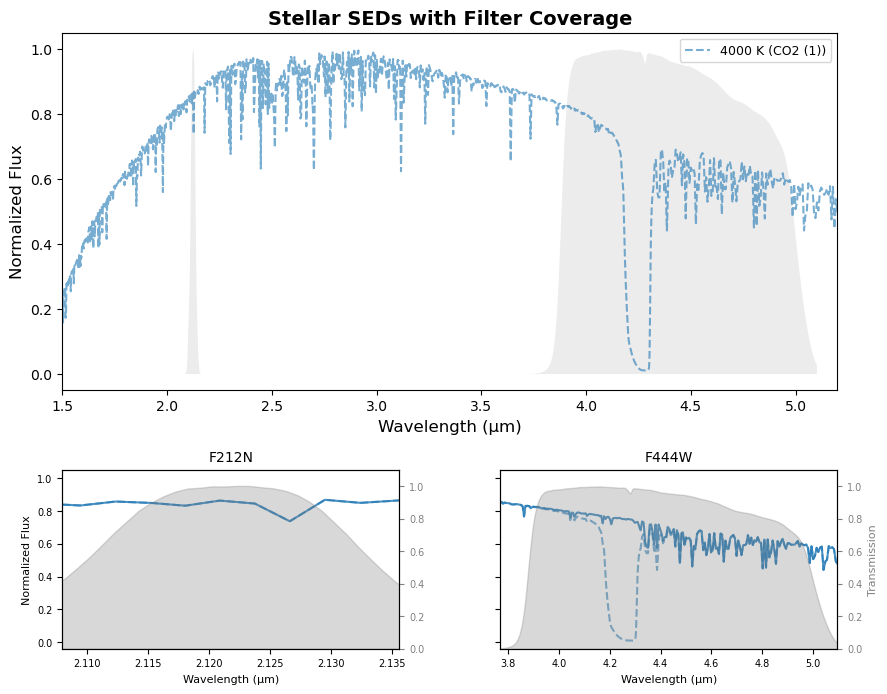

In [14]:
xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)
from dust_extinction.averages import CT06_MWGC

# Reload module
import importlib
import icemodels.plot_seds
importlib.reload(icemodels.plot_seds)
from icemodels import plot_stellar_seds

# Get ice data
co2_table = read_ocdb_file(co2_files[0])

# Plot with both extinction and ice absorption
fig, axes = plot_stellar_seds(
    temperatures=4000,
    logg=2.5,
    filters=['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W'],
    ice_model_table=co2_table,
    ice_column=1e18 * u.cm**-2,
    molecular_weight=44*u.Da,
    extinction_Av=17.0,
    extinction_curve=CT06_MWGC(),
    xarr=xarr_custom
)
plt.show()

In [15]:
# Compute colors for Example 6 (renormalized insets)
inset_filters = ['JWST/NIRCam.F212N', 'JWST/NIRCam.F356W', 'JWST/NIRCam.F410M', 'JWST/NIRCam.F466N']
filter_data_ex6 = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in inset_filters}
transdata_ex6 = {fid: SvoFps.get_transmission_data(fid) for fid in inset_filters}

print("\nComputed Colors with Renormalized Insets:")
print("=" * 70)

stellar_model = atmo_model(4000, xarr=xarr_custom)

# No ice
filter_fluxes_no_ice = fluxes_in_filters(xarr_custom, stellar_model['fnu'].quantity,
                                         filterids=inset_filters, transdata=transdata_ex6)
mags_no_ice = {filt.replace('JWST/NIRCam.', ''): 
               -2.5 * np.log10(filter_fluxes_no_ice[filt] / u.Quantity(filter_data_ex6[filt], u.Jy))
               for filt in inset_filters}

# With CO2 ice (N=1e19 cm^-2)
ice_absorbed_fnu = absorbed_spectrum(ice_column=1e19*u.cm**-2,
                                      ice_model_table=co2_table,
                                      spectrum=stellar_model['fnu'].quantity,
                                      xarr=xarr_custom,
                                      molecular_weight=44*u.Da)

filter_fluxes_ice = fluxes_in_filters(xarr_custom, ice_absorbed_fnu,
                                      filterids=inset_filters, transdata=transdata_ex6)
mags_ice = {filt.replace('JWST/NIRCam.', ''): 
            -2.5 * np.log10(filter_fluxes_ice[filt] / u.Quantity(filter_data_ex6[filt], u.Jy))
            for filt in inset_filters}

filt_names = list(mags_no_ice.keys())

print("\n4000K (no ice):")
for i in range(len(filt_names)-1):
    color = mags_no_ice[filt_names[i]] - mags_no_ice[filt_names[i+1]]
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print("\n4000K (CO2, N=1e19 cm^-2):")
for i in range(len(filt_names)-1):
    color = mags_ice[filt_names[i]] - mags_ice[filt_names[i+1]]
    color_change = color - (mags_no_ice[filt_names[i]] - mags_no_ice[filt_names[i+1]])
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f} (Δcolor: {color_change:+6.3f})")

print("=" * 70)


Computed Colors with Renormalized Insets:

4000K (no ice):
  [F212N] - [F356W]: +0.084
  [F356W] - [F410M]: +0.027
  [F410M] - [F466N]: -0.128

4000K (CO2, N=1e19 cm^-2):
  [F212N] - [F356W]: +0.075 (Δcolor: -0.009)
  [F356W] - [F410M]: -0.543 (Δcolor: -0.569)
  [F410M] - [F466N]: +0.443 (Δcolor: +0.571)


## Example 7: Comparing Scenarios - No Extinction vs Extinction vs Extinction+Ice

This example demonstrates how to plot multiple scenarios on the same figure by reusing axes.

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


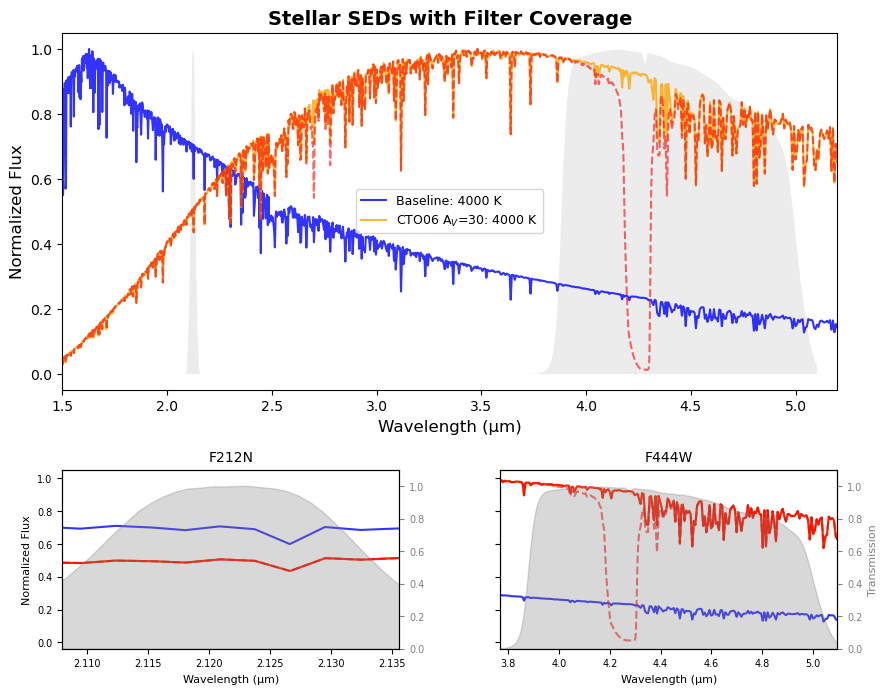

In [16]:
xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

try:
    from dust_extinction.averages import CT06_MWGC
    
    # Reload module to get latest changes
    import importlib
    import icemodels.plot_seds
    importlib.reload(icemodels.plot_seds)
    from icemodels import plot_stellar_seds
    
    # Get ice data
    co2_table = read_ocdb_file(co2_files[0])
    
    # Scenario 1: 4000K, no extinction, no ice (baseline)
    fig, axes = plot_stellar_seds(
        temperatures=4000,
        logg=2.5,
        filters=['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W'],
        xarr=xarr_custom,
        label='Baseline',
        color_cycle=['blue']
    )
    
    # Scenario 2: 4000K, with extinction, no ice (reuse axes)
    fig, axes = plot_stellar_seds(
        temperatures=4000,
        logg=2.5,
        filters=['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W'],
        xarr=xarr_custom,
        extinction_Av=30.0,
        extinction_curve=CT06_MWGC(),
        fig=fig,
        axes=axes,
        label='CTO06 A$_V$=30',
        color_cycle=['orange']
    )
    
    # Scenario 3: 4000K, with extinction + ice (reuse axes again)
    fig, axes = plot_stellar_seds(
        temperatures=4000,
        logg=2.5,
        filters=['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W'],
        xarr=xarr_custom,
        ice_model_table=co2_table,
        ice_column=1e18 * u.cm**-2,
        molecular_weight=44*u.Da,
        extinction_Av=30.0,
        extinction_curve=CT06_MWGC(),
        fig=fig,
        axes=axes,
        label='CT06 A$_V$=30, N(CO$_2$)=10$^{18}$',
        show_ice_absorbed=True,
        color_cycle=['red'],
        show_legend=False
    )
    
    plt.show()
    
except (ImportError, NameError) as e:
    print(f"Skipping comparison example: {e}")

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


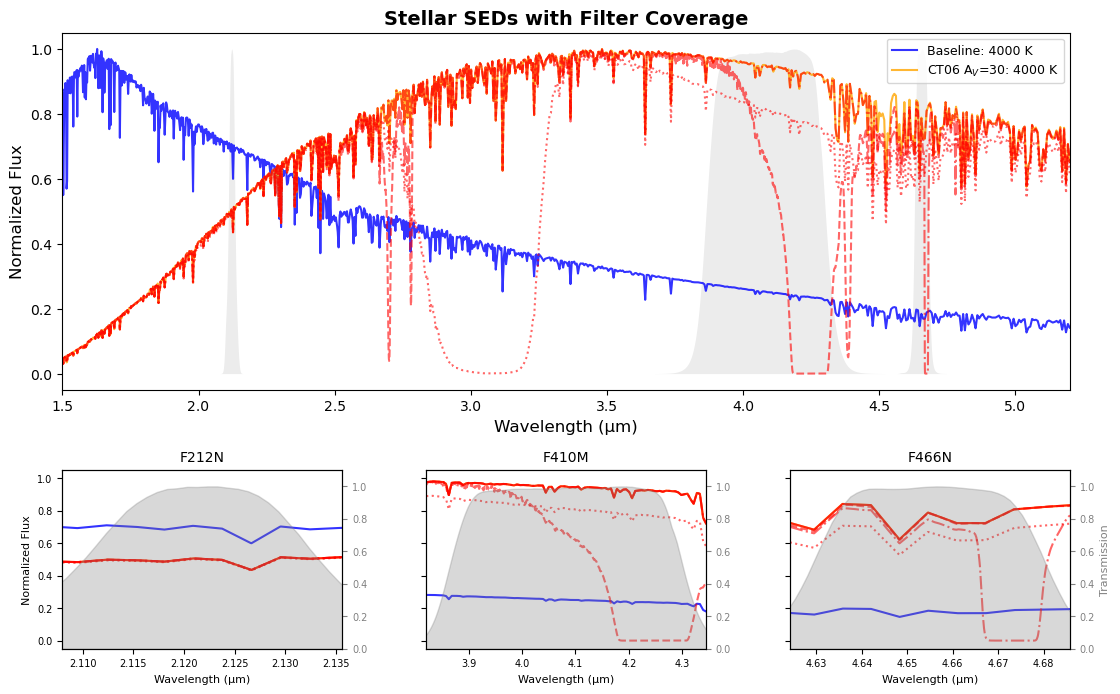

In [17]:
xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

filternames = ['JWST/NIRCam.F212N', 'JWST/NIRCam.F410M', 'JWST/NIRCam.F466N']

from pathlib import Path

try:
    from dust_extinction.averages import CT06_MWGC
    
    # Reload module to get latest changes
    import importlib
    import icemodels.plot_seds
    importlib.reload(icemodels.plot_seds)
    from icemodels import plot_stellar_seds
    
    # Get ice data
    co2_table = read_ocdb_file(co2_files[0])
    
    # Scenario 1: 4000K, no extinction, no ice (baseline)
    fig, axes = plot_stellar_seds(
        temperatures=4000,
        logg=2.5,
        filters=filternames,
        xarr=xarr_custom,
        label='Baseline',
        color_cycle=['blue']
    )
    
    # Scenario 2: 4000K, with extinction, no ice (reuse axes)
    fig, axes = plot_stellar_seds(
        temperatures=4000,
        logg=2.5,
        filters=filternames,
        xarr=xarr_custom,
        extinction_Av=30.0,
        extinction_curve=CT06_MWGC(),
        fig=fig,
        axes=axes,
        label='CT06 A$_V$=30',
        color_cycle=['orange']
    )
    
    # Scenario 3: 4000K, with extinction + ice (reuse axes again)
    fig, axes = plot_stellar_seds(
        temperatures=4000,
        logg=2.5,
        filters=filternames,
        xarr=xarr_custom,
        ice_model_table=[co2_table, co_table, h2o_table],
        ice_column=[1e19*u.cm**-2, 1e19*u.cm**-2, 1e19*u.cm**-2],
        molecular_weight=[44*u.Da, 28*u.Da, 16*u.Da],
        extinction_Av=30.0,
        extinction_curve=CT06_MWGC(),
        fig=fig,
        axes=axes,
        label='CT06 A$_V$=30, N(CO)=N(CO$_2$)=N(H$_2$O)=10$^{18}$',
        show_ice_absorbed=True,
        color_cycle=['red'],
        show_legend=False
    )
    
    output_dir = Path('plots')
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / '4000KStellarSEDexample.png'
    
    # Save the actual figure attached to the plotted axes and force a canvas draw
    fig = axes[0].figure
    fig.canvas.draw()
    fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    
    plt.show()
    
except (ImportError, NameError) as e:
    print(f"Skipping comparison example: {e}")

/blue/adamginsburg/adamginsburg/repos/icemodels/icemodels/plot_seds.py:479: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


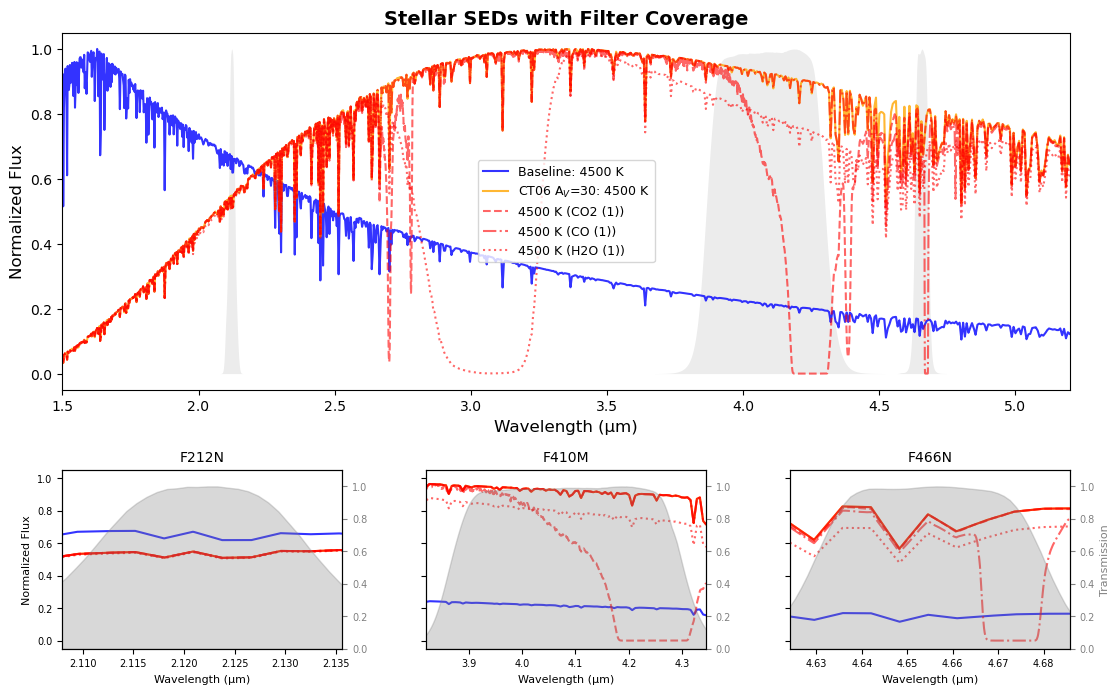

In [18]:
xarr_custom = np.linspace(1.5*u.um, 5.2*u.um, 50000)

filternames = ['JWST/NIRCam.F212N', 'JWST/NIRCam.F410M', 'JWST/NIRCam.F466N']

from pathlib import Path

try:
    from dust_extinction.averages import CT06_MWGC
    
    # Reload module to get latest changes
    import importlib
    import icemodels.plot_seds
    importlib.reload(icemodels.plot_seds)
    from icemodels import plot_stellar_seds
    
    # Get ice data
    co2_table = read_ocdb_file(co2_files[0])
    
    # Scenario 1: 4500K, no extinction, no ice (baseline)
    fig, axes = plot_stellar_seds(
        temperatures=4500,
        logg=2.5,
        filters=filternames,
        xarr=xarr_custom,
        label='Baseline',
        color_cycle=['blue']
    )
    
    # Scenario 2: 4500K, with extinction, no ice (reuse axes)
    fig, axes = plot_stellar_seds(
        temperatures=4500,
        logg=2.5,
        filters=filternames,
        xarr=xarr_custom,
        extinction_Av=30.0,
        extinction_curve=CT06_MWGC(),
        fig=fig,
        axes=axes,
        label='CT06 A$_V$=30',
        color_cycle=['orange']
    )
    
    # Scenario 3: 4500K, with extinction + ice (reuse axes again)
    fig, axes = plot_stellar_seds(
        temperatures=4500,
        logg=2.5,
        filters=filternames,
        xarr=xarr_custom,
        ice_model_table=[co2_table, co_table, h2o_table],
        ice_column=[1e19*u.cm**-2, 1e19*u.cm**-2, 1e19*u.cm**-2],
        molecular_weight=[44*u.Da, 28*u.Da, 16*u.Da],
        extinction_Av=30.0,
        extinction_curve=CT06_MWGC(),
        fig=fig,
        axes=axes,
        label='CT06 A$_V$=30, N(CO)=N(CO$_2$)=N(H$_2$O)=10$^{18}$',
        show_ice_absorbed=True,
        color_cycle=['red']
    )
    
    output_dir = Path('plots')
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / '4500KStellarSEDexample.png'
    
    # Save the actual figure attached to the plotted axes and force a canvas draw
    fig = axes[0].figure
    fig.canvas.draw()
    fig.savefig(output_path, dpi=200, bbox_inches='tight', facecolor='white')
    
    plt.show()
    
except (ImportError, NameError) as e:
    print(f"Skipping comparison example: {e}")

In [19]:
# Compute colors for Example 7 (comparison: baseline vs extinction vs extinction+ice)
comparison_filters = ['JWST/NIRCam.F182M', 'JWST/NIRCam.F212N', 'JWST/NIRCam.F405N', 'JWST/NIRCam.F466N']
filter_data_ex7 = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in comparison_filters}
transdata_ex7 = {fid: SvoFps.get_transmission_data(fid) for fid in comparison_filters}

print("\nComputed Colors - Comparison Example:")
print("=" * 70)

stellar_model = atmo_model(4000, xarr=xarr_custom)

# Scenario 1: Baseline (no extinction, no ice)
filter_fluxes_baseline = fluxes_in_filters(xarr_custom, stellar_model['fnu'].quantity,
                                           filterids=comparison_filters, transdata=transdata_ex7)
mags_baseline = {filt.replace('JWST/NIRCam.', '').replace('JWST/MIRI.', ''): 
                 -2.5 * np.log10(filter_fluxes_baseline[filt] / u.Quantity(filter_data_ex7[filt], u.Jy))
                 for filt in comparison_filters}

# Scenario 2: Extinction (A_V = 17, no ice)
from dust_extinction.averages import CT06_MWGC
ext_curve = CT06_MWGC()
ext_factor = 10**(-0.4 * ext_curve(xarr_custom) * 17)
extinguished_fnu = stellar_model['fnu'].quantity * ext_factor

filter_fluxes_ext = fluxes_in_filters(xarr_custom, extinguished_fnu,
                                      filterids=comparison_filters, transdata=transdata_ex7)
mags_ext = {filt.replace('JWST/NIRCam.', '').replace('JWST/MIRI.', ''): 
            -2.5 * np.log10(filter_fluxes_ext[filt] / u.Quantity(filter_data_ex7[filt], u.Jy))
            for filt in comparison_filters}

# Scenario 3: Extinction + Ice (A_V = 17, CO2 N=1e19 cm^-2)
ice_absorbed_fnu = absorbed_spectrum(ice_column=1e19*u.cm**-2,
                                      ice_model_table=co2_table,
                                      spectrum=extinguished_fnu,
                                      xarr=xarr_custom,
                                      molecular_weight=44*u.Da)

filter_fluxes_ext_ice = fluxes_in_filters(xarr_custom, ice_absorbed_fnu,
                                          filterids=comparison_filters, transdata=transdata_ex7)
mags_ext_ice = {filt.replace('JWST/NIRCam.', '').replace('JWST/MIRI.', ''): 
                -2.5 * np.log10(filter_fluxes_ext_ice[filt] / u.Quantity(filter_data_ex7[filt], u.Jy))
                for filt in comparison_filters}

filt_names = list(mags_baseline.keys())

print("\n4000K Baseline (no extinction, no ice):")
for i in range(len(filt_names)-1):
    color = mags_baseline[filt_names[i]] - mags_baseline[filt_names[i+1]]
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print("\n4000K with Extinction (A_V = 17 mag):")
for i in range(len(filt_names)-1):
    color = mags_ext[filt_names[i]] - mags_ext[filt_names[i+1]]
    color_change = color - (mags_baseline[filt_names[i]] - mags_baseline[filt_names[i+1]])
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f} (Δcolor: {color_change:+6.3f})")

print("\n4000K with Extinction + CO2 Ice (A_V = 17 mag, N=1e19 cm^-2):")
for i in range(len(filt_names)-1):
    color = mags_ext_ice[filt_names[i]] - mags_ext_ice[filt_names[i+1]]
    color_change = color - (mags_baseline[filt_names[i]] - mags_baseline[filt_names[i+1]])
    ice_only_effect = color - (mags_ext[filt_names[i]] - mags_ext[filt_names[i+1]])
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f} (Δcolor from baseline: {color_change:+6.3f}, ice contribution: {ice_only_effect:+6.3f})")

print("=" * 70)


Computed Colors - Comparison Example:



4000K Baseline (no extinction, no ice):
  [F182M] - [F212N]: +0.003
  [F212N] - [F405N]: +0.135
  [F405N] - [F466N]: -0.152

4000K with Extinction (A_V = 17 mag):
  [F182M] - [F212N]: +0.494 (Δcolor: +0.491)
  [F212N] - [F405N]: +1.150 (Δcolor: +1.015)
  [F405N] - [F466N]: -0.067 (Δcolor: +0.085)

4000K with Extinction + CO2 Ice (A_V = 17 mag, N=1e19 cm^-2):
  [F182M] - [F212N]: +0.494 (Δcolor from baseline: +0.491, ice contribution: +0.000)
  [F212N] - [F405N]: +0.874 (Δcolor from baseline: +0.739, ice contribution: -0.276)
  [F405N] - [F466N]: +0.201 (Δcolor from baseline: +0.354, ice contribution: +0.269)


## Example 8: CO Gas Absorption at 1000K

This example demonstrates CO gas absorption on a 4000K stellar SED, comparing cases with and without dust extinction. We use CO at 1000K temperature (hot gas absorption) to show the effect on NIRCam filters.

Could not find atran.txt.  atran atmospheric transition model will not be available


Line profile is not normalized.  Sum is 1
Line profile is not normalized.  Sum is 0.99
Line profile is not normalized.  Sum is 0.98
Line profile is not normalized.  Sum is 0.97
Line profile is not normalized.  Sum is 0.96
Line profile is not normalized.  Sum is 0.95
Line profile is not normalized.  Sum is 0.94
Line profile is not normalized.  Sum is 0.93
Line profile is not normalized.  Sum is 0.92
Line profile is not normalized.  Sum is 0.91
Line profile is not normalized.  Sum is 0.9
Line profile is not normalized.  Sum is 0.89
Line profile is not normalized.  Sum is 0.88
Line profile is not normalized.  Sum is 0.87
Line profile is not normalized.  Sum is 0.86
Line profile is not normalized.  Sum is 0.85
Line profile is not normalized.  Sum is 0.84
Line profile is not normalized.  Sum is 0.83
Line profile is not normalized.  Sum is 0.82
Line profile is not normalized.  Sum is 0.81
Line profile is not normalized.  Sum is 0.8
Line profile is not normalized.  Sum is 0.79
Line profile is

CO gas absorption at T=1000.0 K, N=1e+18 1 / cm2, linewidth=10.0 km / s
Max optical depth: 1.637
Mean optical depth: 0.003

Optical depth in 2.3 μm region (v=0-2 overtone): max=0.007, mean=0.000
Optical depth in 4.6 μm region (v=0-1 fundamental): max=1.637, mean=0.046


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


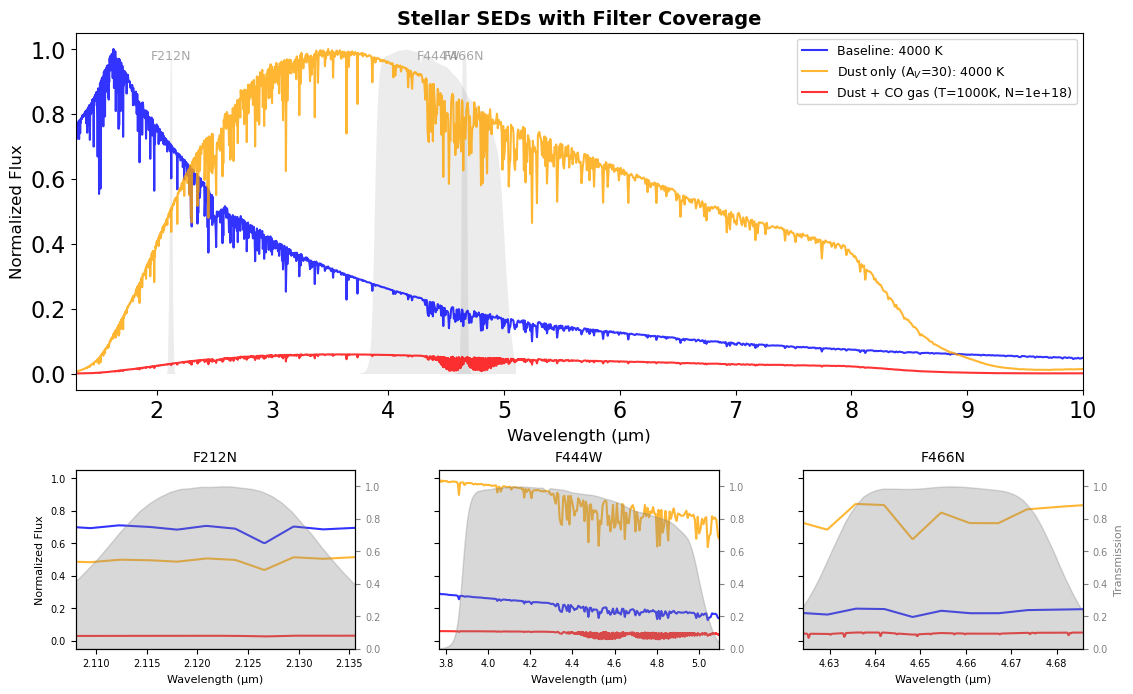


CO gas creates absorption lines visible in the stellar continuum:
  - v=0-2 overtone at ~2.3 μm (visible in F212N filter)
  - v=0-1 fundamental at ~4.6 μm (visible in F444W and F466N filters)
The fundamental is typically stronger than the overtone.


In [20]:
import sys
from brick2221.analysis.co_fundamental_modeling import CO_tau_of_N

from dust_extinction.averages import CT06_MWGC

xarr_custom = np.linspace(1.3*u.um, 10.0*u.um, 50000)

# Reload module to get latest changes
import importlib
import icemodels.plot_seds
importlib.reload(icemodels.plot_seds)
from icemodels import plot_stellar_seds

# CO gas parameters
co_temperature = 1000 * u.K  # Hot CO gas
co_column = 1e18 * u.cm**-2   # CO column density
linewidth = 10 * u.km / u.s   # Line width

# Compute CO gas optical depth using tools from co_fundamental_modeling
# This includes ALL CO vibrational transitions in the wavelength range:
# - v=0-1 fundamental at ~4.6 microns
# - v=0-2 first overtone (harmonic) at ~2.3 microns
tau = CO_tau_of_N(
    xarr_custom.to(u.cm).value,
    co_column.to(u.cm**-2).value,
    co_temperature.to(u.K).value,
    width=linewidth.to(u.km/u.s).value,
    progressbar=lambda x: x,
)

print(f"CO gas absorption at T={co_temperature}, N={co_column}, linewidth={linewidth}")
print(f"Max optical depth: {tau.max():.3f}")
print(f"Mean optical depth: {tau.mean():.3f}")

# Check optical depth in different wavelength regions
mask_23um = (xarr_custom.value > 2.2) & (xarr_custom.value < 2.4)
mask_46um = (xarr_custom.value > 4.5) & (xarr_custom.value < 4.8)
print(f"\nOptical depth in 2.3 μm region (v=0-2 overtone): max={tau[mask_23um].max():.3f}, mean={tau[mask_23um].mean():.3f}")
print(f"Optical depth in 4.6 μm region (v=0-1 fundamental): max={tau[mask_46um].max():.3f}, mean={tau[mask_46um].mean():.3f}")

# Create figure showing three scenarios, with filters covering both transitions
filters_co = ['JWST/NIRCam.F212N', 'JWST/NIRCam.F444W', 'JWST/NIRCam.F466N']

# Scenario 1: Baseline stellar SED (no extinction, no CO gas)
fig, axes = plot_stellar_seds(
    temperatures=4000,
    logg=2.5,
    filters=filters_co,
    xarr=xarr_custom,
    label='Baseline',
    color_cycle=['blue'],
    label_filters=True,
)

# Scenario 2: With dust extinction (A_V=30), no CO gas
fig, axes = plot_stellar_seds(
    temperatures=4000,
    logg=2.5,
    filters=filters_co,
    xarr=xarr_custom,
    extinction_Av=30.0,
    extinction_curve=CT06_MWGC(),
    fig=fig,
    axes=axes,
    label='Dust only (A$_V$=30)',
    color_cycle=['orange']
)

# Scenario 3: With dust extinction AND CO gas absorption
# We need to manually apply CO absorption to the stellar SED
from icemodels import atmo_model

stellar_model = atmo_model(4000, xarr=xarr_custom, logg=2.5)
base_flux = stellar_model['fnu'].quantity

# Apply dust extinction
ext_curve = CT06_MWGC()
x = 1.0 / xarr_custom.to(u.um).value
valid = (x >= ext_curve.x_range[0]) & (x <= ext_curve.x_range[1])
ext_alambda_av = np.zeros_like(x)
if np.any(valid):
    ext_alambda_av[valid] = ext_curve(x[valid] / u.um)
ext_mag = ext_alambda_av * 30.0
extinguished_flux = base_flux * 10**(-ext_mag / 2.5)

# Apply CO gas absorption
co_absorbed_flux = extinguished_flux * np.exp(-tau)

# Normalize to match stellar SED normalization
co_absorbed_norm = co_absorbed_flux / base_flux.max()

# Plot on main axes
axes[0].plot(xarr_custom.value, co_absorbed_norm.value, 
            color='red', linewidth=1.5, alpha=0.8,
            label=f'Dust + CO gas (T={co_temperature.value:.0f}K, N={co_column.value:.0e})')

# Plot on zoom axes too
for ax_zoom in axes[1:]:
    ax_zoom.plot(xarr_custom.value, co_absorbed_norm.value, 
                color='red', linewidth=1.5, alpha=0.8)

# Update legend
axes[0].legend(loc='best', fontsize=9)

plt.show()

print(f"\nCO gas creates absorption lines visible in the stellar continuum:")
print(f"  - v=0-2 overtone at ~2.3 μm (visible in F212N filter)")
print(f"  - v=0-1 fundamental at ~4.6 μm (visible in F444W and F466N filters)")
print(f"The fundamental is typically stronger than the overtone.")

In [21]:
# Compute colors for Example 8 (CO gas absorption comparison)
filter_data_ex8 = {fid: float(jfilts.loc[fid]['ZeroPoint']) for fid in filters_co}
transdata_ex8 = {fid: SvoFps.get_transmission_data(fid) for fid in filters_co}

print("\nComputed Colors - CO Gas Absorption at 1000K:")
print("=" * 70)

stellar_model = atmo_model(4000, xarr=xarr_custom)
base_flux = stellar_model['fnu'].quantity

# Scenario 1: Baseline (no extinction, no CO gas)
filter_fluxes_baseline = fluxes_in_filters(xarr_custom, base_flux,
                                           filterids=filters_co, transdata=transdata_ex8)
mags_baseline = {filt.replace('JWST/NIRCam.', ''): 
                 -2.5 * np.log10(filter_fluxes_baseline[filt] / u.Quantity(filter_data_ex8[filt], u.Jy))
                 for filt in filters_co}

# Scenario 2: Dust only (A_V = 30)
ext_curve = CT06_MWGC()
x = 1.0 / xarr_custom.to(u.um).value
valid = (x >= ext_curve.x_range[0]) & (x <= ext_curve.x_range[1])
ext_alambda_av = np.zeros_like(x)
if np.any(valid):
    ext_alambda_av[valid] = ext_curve(x[valid] / u.um)
ext_mag = ext_alambda_av * 30.0
extinguished_flux = base_flux * 10**(-ext_mag / 2.5)

filter_fluxes_dust = fluxes_in_filters(xarr_custom, extinguished_flux,
                                       filterids=filters_co, transdata=transdata_ex8)
mags_dust = {filt.replace('JWST/NIRCam.', ''): 
             -2.5 * np.log10(filter_fluxes_dust[filt] / u.Quantity(filter_data_ex8[filt], u.Jy))
             for filt in filters_co}

# Scenario 3: Dust + CO gas absorption
# Recompute tau for consistency
tau = CO_tau_of_N(
    xarr_custom.to(u.cm).value,
    co_column.to(u.cm**-2).value,
    co_temperature.to(u.K).value,
    width=linewidth.to(u.km/u.s).value,
    progressbar=lambda x: x,
)
co_absorbed_flux = extinguished_flux * np.exp(-tau)

filter_fluxes_dust_co = fluxes_in_filters(xarr_custom, co_absorbed_flux,
                                          filterids=filters_co, transdata=transdata_ex8)
mags_dust_co = {filt.replace('JWST/NIRCam.', ''): 
                -2.5 * np.log10(filter_fluxes_dust_co[filt] / u.Quantity(filter_data_ex8[filt], u.Jy))
                for filt in filters_co}

filt_names = list(mags_baseline.keys())

print(f"\n4000K Baseline (no extinction, no CO gas):")
for i in range(len(filt_names)-1):
    color = mags_baseline[filt_names[i]] - mags_baseline[filt_names[i+1]]
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f}")

print(f"\n4000K with Dust only (A_V = 30 mag):")
for i in range(len(filt_names)-1):
    color = mags_dust[filt_names[i]] - mags_dust[filt_names[i+1]]
    color_change = color - (mags_baseline[filt_names[i]] - mags_baseline[filt_names[i+1]])
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f} (Δcolor: {color_change:+6.3f})")

print(f"\n4000K with Dust + CO gas (A_V = 30 mag, T_CO={co_temperature.value:.0f}K, N={co_column.value:.0e}):")
for i in range(len(filt_names)-1):
    color = mags_dust_co[filt_names[i]] - mags_dust_co[filt_names[i+1]]
    color_change = color - (mags_baseline[filt_names[i]] - mags_baseline[filt_names[i+1]])
    co_only_effect = color - (mags_dust[filt_names[i]] - mags_dust[filt_names[i+1]])
    print(f"  [{filt_names[i]}] - [{filt_names[i+1]}]: {color:+6.3f} (Δcolor from baseline: {color_change:+6.3f}, CO gas contribution: {co_only_effect:+6.3f})")

print("=" * 70)
print(f"\nNote: CO gas absorption at 1000K creates narrow line absorption features:")
print(f"  - F212N (~2.1 μm) captures the v=0-2 overtone at ~2.3 μm")
print(f"  - F444W and F466N (~4.4-4.7 μm) capture the v=0-1 fundamental at ~4.6 μm")
print(f"The fundamental transition is typically much stronger than the overtone.")


Computed Colors - CO Gas Absorption at 1000K:


Line profile is not normalized.  Sum is 1
Line profile is not normalized.  Sum is 0.99
Line profile is not normalized.  Sum is 0.98
Line profile is not normalized.  Sum is 0.97
Line profile is not normalized.  Sum is 0.96
Line profile is not normalized.  Sum is 0.95
Line profile is not normalized.  Sum is 0.94
Line profile is not normalized.  Sum is 0.93
Line profile is not normalized.  Sum is 0.92
Line profile is not normalized.  Sum is 0.91
Line profile is not normalized.  Sum is 0.9
Line profile is not normalized.  Sum is 0.89
Line profile is not normalized.  Sum is 0.88
Line profile is not normalized.  Sum is 0.87
Line profile is not normalized.  Sum is 0.86
Line profile is not normalized.  Sum is 0.85
Line profile is not normalized.  Sum is 0.84
Line profile is not normalized.  Sum is 0.83
Line profile is not normalized.  Sum is 0.82
Line profile is not normalized.  Sum is 0.81
Line profile is not normalized.  Sum is 0.8
Line profile is not normalized.  Sum is 0.79
Line profile is


4000K Baseline (no extinction, no CO gas):
  [F212N] - [F444W]: +0.036
  [F444W] - [F466N]: -0.053

4000K with Dust only (A_V = 30 mag):
  [F212N] - [F444W]: +1.904 (Δcolor: +1.868)
  [F444W] - [F466N]: +0.020 (Δcolor: +0.073)

4000K with Dust + CO gas (A_V = 30 mag, T_CO=1000K, N=1e+18):
  [F212N] - [F444W]: +1.890 (Δcolor from baseline: +1.854, CO gas contribution: -0.014)
  [F444W] - [F466N]: +0.007 (Δcolor from baseline: +0.060, CO gas contribution: -0.012)

Note: CO gas absorption at 1000K creates narrow line absorption features:
  - F212N (~2.1 μm) captures the v=0-2 overtone at ~2.3 μm
  - F444W and F466N (~4.4-4.7 μm) capture the v=0-1 fundamental at ~4.6 μm
The fundamental transition is typically much stronger than the overtone.


Line profile is not normalized.  Sum is 0.082
Line profile is not normalized.  Sum is 0.095


## Example: Same Temperature (3500K), Different Luminosity Classes

This comparison uses class-dependent atmosphere models (different surface gravities, `logg`) at fixed temperature.
Each spectrum is normalized to the same peak flux so the differences reflect spectral shape/colors only, not absolute luminosity.

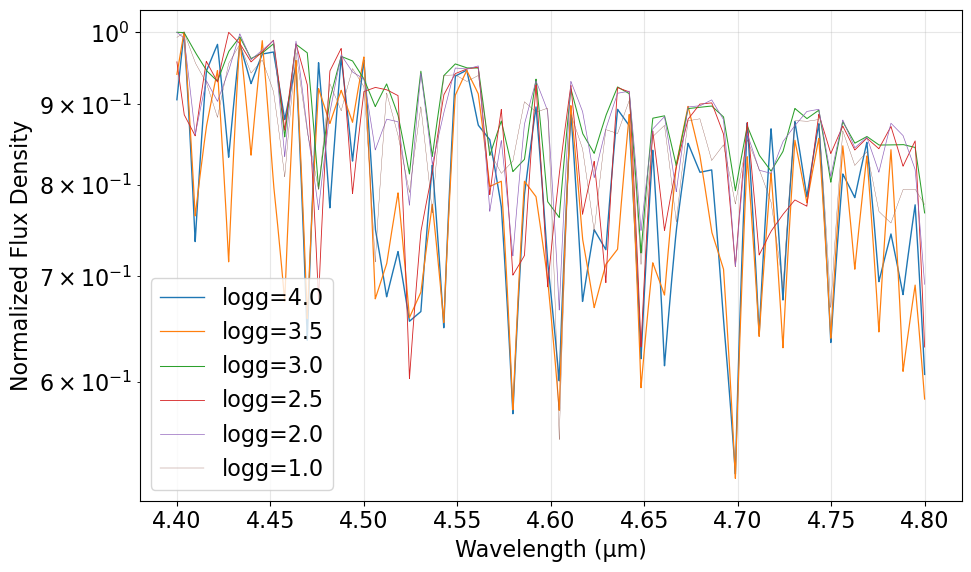

In [26]:
# Compare 4500K stars at fixed logg=2.5
temp_lc = 4500
xarr_lc = np.linspace(0.6, 28.0, 25000) * u.um
xarr_lc = np.linspace(3.6, 5.0, 25000) * u.um
xarr_lc = np.linspace(4.4, 4.8, 25000) * u.um
fig, ax = plt.subplots(figsize=(10, 6))
for logg in (1, 2, 2.5, 3, 3.5, 4)[::-1]:

    stellar_model = atmo_model(temp_lc, xarr=xarr_lc, logg=logg)
    flux = stellar_model['fnu'].quantity
    flux_norm = flux / flux.max()

    ax.plot(xarr_lc.to_value(u.um), flux_norm, linewidth=logg/4, label=f'logg={logg:.1f}')

ax.set_xlabel('Wavelength (μm)')
ax.set_ylabel('Normalized Flux Density')
ax.set_yscale('log')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()